# Learning SIR Models with Python: A COVID-19 Example

## Introduction

This notebook demonstrates how to use the `sir_modeling.py` module to construct, simulate, and visualize a basic Susceptible-Infected-Recovered (SIR) epidemiological model.

This repository originated as a final project for COGS 18 (Introduction to Python) at the University of California, San Diego. The original project focused on applying an SIR model to publicly available COVID-19 data. The project has since been refactored into a reusable Python module for constructing, simulating, and visualizing SIR models, with an emphasis on educational exploration of compartmental epidemic modeling.

To demonstrate the functionality of the module, this notebook uses publicly available COVID-19 case surveillance data from the Centers for Disease Control and Prevention (CDC) together with state population estimates from the United States Census Bureau.

The goals of this notebook are to:

1. Introduce the concepts underlying SIR models.
2. Explain the mathematical formulation of the model.
3. Demonstrate how the model is implemented in Python.
4. Apply the model to a real-world COVID-19 dataset.
5. Visualize and interpret model behavior.
6. Discuss limitations and possible extensions.

## Table of Contents

1. [Background: The SIR Model](#1-background-the-sir-model)

2. [Mathematical Formulation](#2-mathematical-formulation)
   - [2.1 Change in the Susceptible Population](#21-change-in-the-susceptible-population)
   - [2.2 Change in the Infected Population](#22-change-in-the-infected-population)
   - [2.3 Change in the Recovered Population](#23-change-in-the-recovered-population)
   - [2.4 Model Parameters](#24-model-parameters)

3. [Implementation in Python](#3-implementation-in-python)
   - [3.1 Example: Simulating a Simple Outbreak](#31-example-simulating-a-simple-outbreak)
   - [3.2 Interpreting the Results](#32-interpreting-the-results)

4. [COVID-19 Data Sources](#4-covid-19-data-sources)

5. [Data Preparation](#5-data-preparation)
   - [5.1 Exploratory Analysis (EDA)](#51-exploratory-analysis-eda)
   - [5.1.1 Total Reported Cases](#511-total-reported-cases)
   - [5.1.2 Daily New Cases](#512-daily-new-cases)

6. [Constructing Initial Conditions](#6-constructing-initial-conditions)
   - [6.1 Estimating Active Infections](#61-estimating-active-infections)
   - [6.2 Selecting Comparison Dates](#62-selecting-comparison-dates)
   - [6.3 Population Estimates](#63-population-estimates)
   - [6.4 Estimating S-I-and-R](#64-estimating-s-i-and-r)
   - [6.5 Scaling Initial Conditions](#65-scaling-initial-conditions)

7. [Running and Visualizing the SIR Model](#7-running-and-visualizing-the-sir-model)
   - [7.1 California: October 18, 2020](#71-california-october-18-2020)
   - [7.2 California: October 18, 2021](#72-california-october-18-2021)
   - [7.3 California: October 18, 2022](#73-california-october-18-2022)
   - [7.4 Comparing Simulations Across Years](#74-comparing-simulations-across-years)

8. [Sensitivity Analysis](#8-sensitivity-analysis)

9. [Discussion and Limitations](#9-discussion-and-limitations)

10. [Conclusions](#10-conclusions)

11. [References](#11-references)

# 1. Background: The SIR Model

Compartmental models are among the most widely used mathematical models in epidemiology. These models divide a population into groups representing different stages of disease progression.

The SIR model separates a population into three compartments:

- **Susceptible (S):** individuals who can become infected.
- **Infected (I):** individuals who are currently infected and capable of transmitting disease.
- **Recovered (R):** individuals who have recovered and are assumed to possess immunity.

Individuals transition between compartments according to disease transmission and recovery dynamics:

Susceptible → Infected → Recovered

The model assumes a closed population in which individuals progress through these compartments without births, deaths unrelated to the disease, or migration.

Although highly simplified, SIR models provide valuable insight into epidemic growth, peak infection levels, and recovery patterns.

# 2. Mathematical Formulation

The SIR model describes how individuals move between the susceptible, infected, and recovered compartments over time.

These changes are represented by a system of ordinary differential equations (ODEs). Each equation describes the rate of change of one compartment as a function of the current population state.

Together, these equations allow us to model the progression of an infectious disease through a population.

For simplicity, the SIR model is often expressed in terms of population proportions rather than raw population counts. This allows the model to be applied to populations of different sizes while preserving the same underlying dynamics.

## 2.1 Change in the Susceptible Population

The susceptible population decreases when susceptible individuals come into contact with infected individuals and become infected.

$$\frac{dS}{dt}=-\beta SI$$

The parameter $\beta$ controls the transmission rate of the disease. Larger values of $\beta$ correspond to faster disease spread.

## 2.2 Change in the Infected Population

The infected population changes through two competing processes:

1. New infections increase the infected population.
2. Recoveries decrease the infected population.

$$\frac{dI}{dt}=\beta SI-\gamma I$$

The first term represents new infections, while the second term represents individuals leaving the infected compartment through recovery.

## 2.3 Change in the Recovered Population

Recovered individuals are generated when infected individuals recover from the disease.

$$\frac{dR}{dt}=\gamma I$$

The recovery rate parameter $\gamma$ determines how quickly infected individuals move into the recovered compartment.

## 2.4 Model Parameters

The behavior of the SIR model is primarily controlled by two parameters:

- $\beta$: transmission rate
- $\gamma$: recovery rate

Higher values of $\beta$ generally produce faster epidemic growth, while higher values of $\gamma$ shorten the infectious period and accelerate recovery.

By adjusting these parameters, we can explore how different disease characteristics influence epidemic dynamics.

# 3. Implementation in Python

The previous section introduced the mathematical foundations of the SIR model. The next step is translating those equations into Python so the model can be simulated numerically.

The `sir_modeling.py` module included in this repository implements the SIR framework described above. Rather than writing all modeling code directly inside this notebook, the main functions are stored in a separate Python file so they can be reused across different examples or datasets.

The module provides functions for:

- Creating initial SIR conditions
- Numerically solving the SIR differential equation system
- Visualizing model results

The module is imported below.

In [3]:
import sir_modeling as sir

## 3.1 Example: Simulating a Simple Outbreak

Before applying the model to real COVID-19 data, it is helpful to demonstrate the workflow using a small hypothetical example.

Suppose a population contains:

- 990 susceptible individuals
- 10 infected individuals
- 0 recovered individuals

These values represent the starting point of the simulation. In other words, the outbreak begins with a small number of infected individuals in an otherwise susceptible population.

In [8]:
initial_conditions = sir.calculate_initial_conditions(
    susceptible=990,
    infected=10,
    recovered=0
)

initial_conditions

[0.99, 0.01, 0.0]

The function converts the raw population counts into proportions. In this example, the initial conditions are:

- $S_0 = 0.99$
- $I_0 = 0.01$
- $R_0 = 0.00$

These values sum to 1, meaning the entire population is accounted for across the three compartments.

In [9]:
sum(initial_conditions)

1.0

Next, the initial conditions are passed to the SIR model solver.

For this demonstration, we choose:

- $\beta = 0.3$, the transmission rate
- $\gamma = 0.1$, the recovery rate
- 160 days as the simulation period

These parameter values are hypothetical and are used only to demonstrate the behavior of the model.

In [5]:
t, results = sir.run_sir_model(
    initial_conditions=initial_conditions,
    beta=0.3,
    gamma=0.1,
    days=160
)

The output contains two objects:

- `t`: the time points used in the simulation
- `results`: the estimated SIR values at each time point

The `results` object contains three columns corresponding to susceptible, infected, and recovered population proportions.

In [10]:
results[:5]

array([[9.90000000e-01, 1.00000000e-02, 0.00000000e+00],
       [9.89516846e-01, 1.03204360e-02, 1.62718121e-04],
       [9.89018467e-01, 1.06508859e-02, 3.30646719e-04],
       [9.88504435e-01, 1.09916268e-02, 5.03938095e-04],
       [9.87974231e-01, 1.13429930e-02, 6.82775944e-04]])

The resulting trajectories can then be visualized using the plotting function from `sir_modeling.py`.

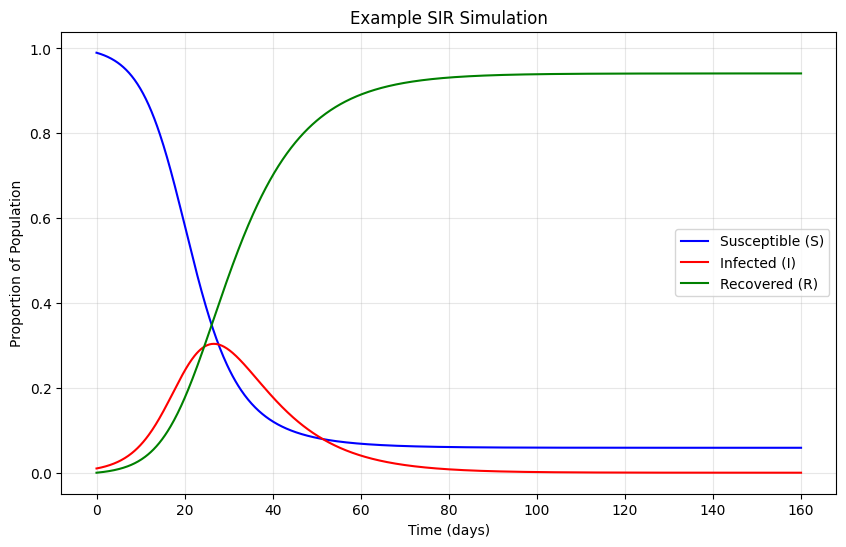

<Axes: title={'center': 'Example SIR Simulation'}, xlabel='Time (days)', ylabel='Proportion of Population'>

In [6]:
sir.plot_sir_model(
    t,
    results,
    title="Example SIR Simulation"
)

## 3.2 Interpreting the Results

The plot shows the characteristic behavior of a basic SIR model.

At the beginning of the simulation, most individuals are susceptible and only a small proportion of the population is infected. Because there are many susceptible individuals available, infections initially increase.

As the outbreak progresses, susceptible individuals move into the infected compartment and then eventually into the recovered compartment. The susceptible curve decreases, the infected curve rises and later falls, and the recovered curve increases over time.

The infected population does not increase indefinitely. Eventually, the susceptible population becomes small enough that new infections slow down. At that point, recoveries begin to outpace new infections, causing the infected curve to decline.

This simple example illustrates how the SIR framework captures the rise and decline of an epidemic using only a small number of assumptions and parameters.

---

The previous example demonstrated the mechanics of running an SIR simulation using a hypothetical population. The remainder of this notebook applies the same workflow to real-world COVID-19 surveillance data from California.

The goal is not to produce a definitive epidemiological forecast. Instead, the objective is to demonstrate how publicly available data can be transformed into model inputs and used to explore epidemic dynamics within the SIR framework.

# 4. COVID-19 Data Sources

To demonstrate the SIR modeling workflow, publicly available COVID-19 surveillance data from the Centers for Disease Control and Prevention (CDC) are combined with annual state population estimates from the United States Census Bureau.

The CDC dataset contains daily state-level observations, including cumulative cases, new cases, cumulative deaths, and new deaths reported throughout the COVID-19 pandemic.

Population estimates are obtained from the Census Bureau's Population Estimates Program and are used to scale model quantities and construct population-level initial conditions.

Data Sources:

- CDC: United States COVID-19 Cases and Deaths by State Over Time
- U.S. Census Bureau: State Population Estimates Program

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

covid = pd.read_csv(
    "data/covid_cases_by_state_archived.csv"
)

population = pd.read_excel(
    "data/state_population_estimates.xlsx"
)

In [31]:
covid.head()

,submission_date,state,tot_cases,conf_cases,prob_cases,new_case,pnew_case,tot_death,conf_death,prob_death,new_death,pnew_death,created_at,consent_cases,consent_deaths
0,03/11/2021,KS,297229,241035.0,56194.0,0,0.0,4851,NaN,NaN,0,0.0,03/12/2021 03:20:13 PM,Agree,NaN
1,12/01/2021,ND,163565,135705.0,27860.0,589,220.0,1907,NaN,NaN,9,0.0,12/02/2021 02:35:20 PM,Agree,Not agree
2,01/02/2022,AS,11,NaN,NaN,0,0.0,0,NaN,NaN,0,0.0,01/03/2022 03:18:16 PM,NaN,NaN
3,11/22/2021,AL,841461,620483.0,220978.0,703,357.0,16377,12727.0,3650.0,7,3.0,11/22/2021 12:00:00 AM,Agree,Agree
4,05/30/2022,AK,251425,NaN,NaN,0,0.0,1252,NaN,NaN,0,0.0,05/31/2022 01:20:20 PM,NaN,NaN


In [32]:
population.head()

,geo_area,pop_baseline_2020,pop_2020,pop_2021,pop_2022,pop_2023,pop_2024,pop_2025
0,United States,331516113,331578104,332100166,333996304,336755052,340003797,341784857
1,Northeast,57617560,57436027,57234503,57174375,57458539,57940522,58042054
2,Midwest,68999462,68979566,68867096,68872112,69132050,69518281,69762666
3,South,126281605,126473371,127380165,129066102,130894372,132662072,133833983
4,West,78617486,78689140,78618402,78883715,79270091,79882922,80146154


# 5. Data Preparation

Before constructing SIR model inputs, the COVID-19 surveillance data must be prepared.

For the purposes of this analysis, only a subset of variables are required:

- submission_date
- state
- tot_cases
- new_case
- tot_death
- new_death

California is selected as the example state because it contains a complete time series spanning the study period and provides a useful case study for exploring epidemic dynamics.

In [33]:
covid = covid[
    [
        "submission_date",
        "state",
        "tot_cases",
        "new_case",
        "tot_death",
        "new_death"
    ]
].copy()

covid["submission_date"] = pd.to_datetime(
    covid["submission_date"]
)

ca = covid[covid["state"] == "CA"].copy()

ca = ca.sort_values("submission_date")

## 5.1 Exploratory Analysis

### 5.1.1 Total Reported Cases

The cumulative case count provides a broad overview of how the pandemic evolved over time.

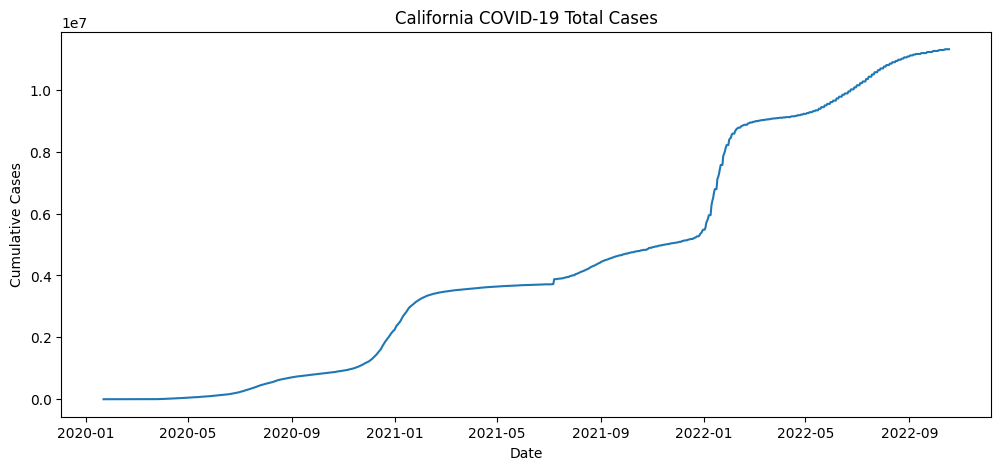

In [34]:
plt.figure(figsize=(12,5))
plt.plot(
    ca["submission_date"],
    ca["tot_cases"]
)
plt.title("California COVID-19 Total Cases")
plt.xlabel("Date")
plt.ylabel("Cumulative Cases")
plt.show()

As expected, cumulative cases increase monotonically throughout the study period. While useful for measuring the overall scale of the pandemic, cumulative counts are not directly suitable for representing the currently infected population required by an SIR model.

### 5.1.2 Daily New Cases

Daily reported cases provide insight into changes in disease activity throughout the pandemic.

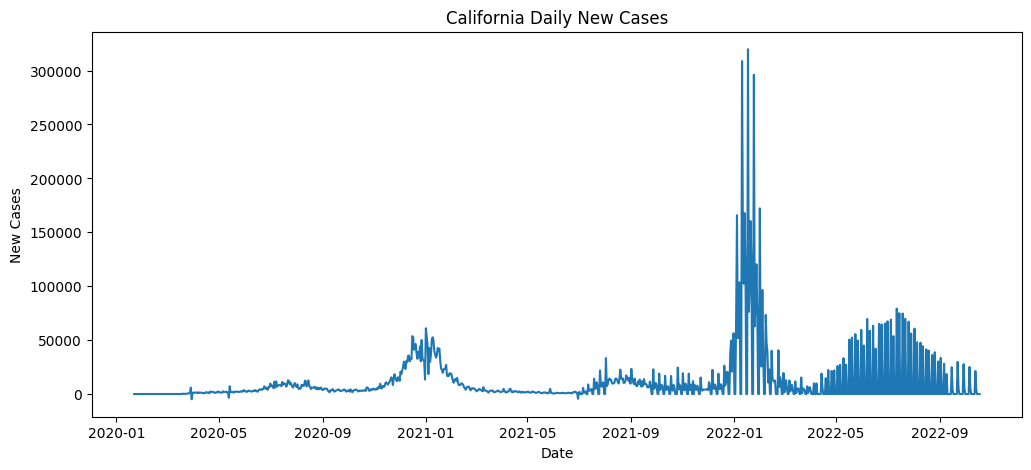

In [35]:
plt.figure(figsize=(12,5))
plt.plot(
    ca["submission_date"],
    ca["new_case"]
)
plt.title("California Daily New Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

Several major waves are visible, including a pronounced surge during early 2022. These fluctuations highlight the dynamic nature of disease transmission and motivate the need for methods that approximate active infections from reported case counts.

# 6. Constructing Initial Conditions

The SIR model requires estimates of susceptible, infected, and recovered populations at the beginning of the simulation.

While cumulative case counts and deaths are available directly from the CDC dataset, active infections are not reported explicitly. Therefore, an approximation is required.

## 6.1 Estimating Active Infections

A common approximation is to treat individuals reported within the previous 14 days as currently infectious.

This assumption is consistent with an average infectious period of approximately two weeks and provides a simple method for estimating the active infected population.

In [37]:
ca["active_cases"] = (
    ca["new_case"]
    .rolling(window=14)
    .sum()
)

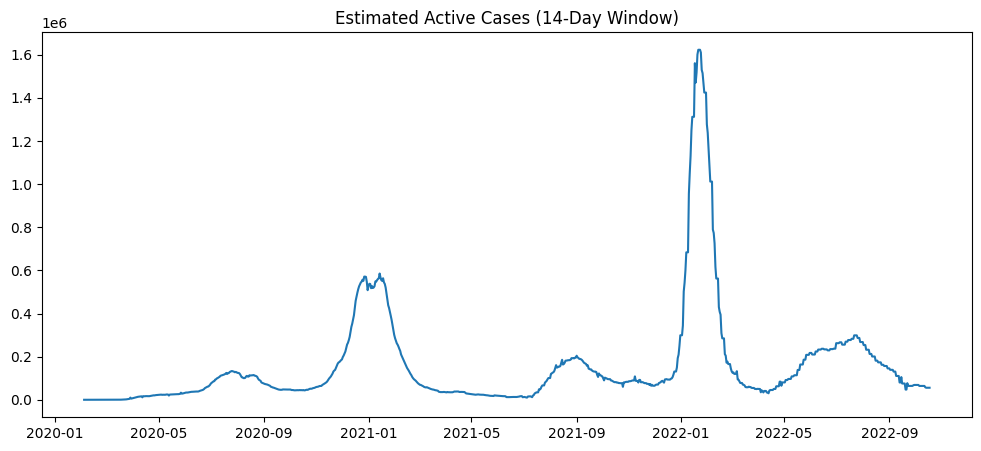

In [38]:
plt.figure(figsize=(12,5))
plt.plot(
    ca["submission_date"],
    ca["active_cases"]
)
plt.title("Estimated Active Cases (14-Day Window)")
plt.show()

This estimate will be used as the infected compartment when constructing the initial conditions for the SIR model.

## 6.2 Selecting Comparison Dates

To demonstrate how epidemic conditions changed throughout the COVID-19 pandemic, three dates are selected for comparison:

- October 18, 2020
- October 18, 2021
- October 18, 2022

These dates provide approximately annual snapshots of the pandemic and allow the SIR model to be initialized under different epidemic conditions.

For each date, susceptible, infected, and recovered populations will be estimated using California COVID-19 surveillance data together with annual population estimates from the U.S. Census Bureau.

In [39]:
comparison_dates = [
    "2020-10-18",
    "2021-10-18",
    "2022-10-18"
]

snapshots = ca[
    ca["submission_date"].isin(
        pd.to_datetime(comparison_dates)
    )
].copy()

snapshots[
    [
        "submission_date",
        "tot_cases",
        "active_cases",
        "tot_death"
    ]
]

,submission_date,tot_cases,active_cases,tot_death
31246,2020-10-18,867317,43588.0,16883
33078,2021-10-18,4804462,79549.0,70416
28617,2022-10-18,11309237,55784.0,95604


The selected observations contain the cumulative case counts, estimated active infections, and cumulative deaths used to construct the SIR model inputs.

## 6.3 Population Estimates

To estimate the susceptible population, annual population estimates from the U.S. Census Bureau are incorporated into the analysis.

Because the selected COVID-19 observations span multiple years, the corresponding annual California population estimate is used for each year. This ensures that population-based calculations remain consistent with the period being analyzed.

In [42]:
ca_population = population[
    population["geo_area"] == ".California"
]

ca_population[
    [
        "pop_2020",
        "pop_2021",
        "pop_2022"
    ]
]

,pop_2020,pop_2021,pop_2022
9,39527808,39152927,39125347


## 6.4 Estimating S, I, and R

The CDC dataset does not directly report susceptible, infected, and recovered populations. Therefore, these quantities must be estimated from the available surveillance data.

For each selected year, the infected population is approximated using the 14-day active case estimate developed earlier.

The recovered population is estimated as:

$$
\text{Recovered} = \text{Total Cases} - \text{Active Cases} - \text{Total Deaths}
$$

This approximation assumes that individuals who were previously infected but are no longer counted as active cases have either recovered or died.

Using mathematical notation, this relationship can be written as:

$$
R = C - I - D
$$

where:

- \(R\) is the recovered population,
- \(C\) is the cumulative reported case count,
- \(I\) is the estimated active infected population, and
- \(D\) is the cumulative death count.

Finally, the susceptible population is estimated as:

$$
\text{Susceptible} = \text{Population} - \text{Infected} - \text{Recovered} - \text{Deaths}
$$

or equivalently,

$$
S = N - I - R - D
$$

where:

- \(S\) is the susceptible population,
- \(N\) is the total population,
- \(I\) is the estimated active infected population,
- \(R\) is the recovered population, and
- \(D\) is the cumulative death count.

Together, these estimates provide the initial conditions required by the SIR model.

In [43]:
population_lookup = {
    2020: int(ca_population["pop_2020"].iloc[0]),
    2021: int(ca_population["pop_2021"].iloc[0]),
    2022: int(ca_population["pop_2022"].iloc[0])
}

records = []

for _, row in snapshots.iterrows():

    year = row["submission_date"].year

    population_size = population_lookup[year]

    infected = row["active_cases"]

    recovered = (
        row["tot_cases"]
        - infected
        - row["tot_death"]
    )

    susceptible = (
        population_size
        - infected
        - recovered
        - row["tot_death"]
    )

    records.append(
        {
            "Year": year,
            "Population": population_size,
            "Susceptible": susceptible,
            "Infected": infected,
            "Recovered": recovered,
            "Deaths": row["tot_death"]
        }
    )

sir_inputs = pd.DataFrame(records)

sir_inputs

,Year,Population,Susceptible,Infected,Recovered,Deaths
0,2020,39527808,38660491.0,43588.0,806846.0,16883
1,2021,39152927,34348465.0,79549.0,4654497.0,70416
2,2022,39125347,27816110.0,55784.0,11157849.0,95604


The estimated compartment sizes reveal how the pandemic evolved over time in California.

In 2020, the overwhelming majority of the population remained susceptible, while relatively few individuals had experienced infection. By 2021 and especially 2022, cumulative infections had increased substantially, resulting in a much larger recovered population and a corresponding reduction in the susceptible population.

Although active infections fluctuated throughout the pandemic, they represent only a small fraction of the total population in each snapshot. In contrast, the recovered compartment grows considerably across years as more individuals are estimated to have previously experienced infection.

These estimated compartment values provide the initial conditions used to initialize the SIR model simulations in the following sections.

## 6.5 Scaling Initial Conditions
The `sir_modeling.py` module operates on population proportions rather than raw population counts.

Therefore, the estimated susceptible, infected, and recovered populations are scaled by the corresponding annual population estimate before being supplied to the model.

Scaling ensures that the compartment values sum to one and allows simulations to be compared across years despite differences in population size.

In [46]:
scaled_conditions = {}

for _, row in sir_inputs.iterrows():

    conditions = sir.calculate_initial_conditions(
        susceptible=row["Susceptible"],
        infected=row["Infected"],
        recovered=row["Recovered"]
    )

    scaled_conditions[int(row["Year"])] = conditions

scaled_df = pd.DataFrame.from_dict(
    scaled_conditions,
    orient="index",
    columns=[
        "Susceptible",
        "Infected",
        "Recovered"
    ]
)

scaled_df.index.name = "Year"

scaled_df

,Susceptible,Infected,Recovered
Year,,,
2020,0.978476,0.001103,0.020421
2021,0.878870,0.002035,0.119094
2022,0.712690,0.001429,0.285881


The resulting values represent the proportion of the population that is susceptible, infected, or recovered at the beginning of each simulation.

The normalized initial conditions reveal substantial changes in the population composition across years. The proportion of susceptible individuals declines steadily from approximately 98% in 2020 to 71% in 2022. At the same time, the recovered compartment grows from roughly 2% to nearly 29% of the population. These changes reflect the cumulative impact of COVID-19 infections throughout the pandemic and illustrate how the starting conditions of an epidemic model can vary substantially over time.

These normalized values will be used as the initial conditions for the SIR model in the next section.

# 7. Running and Visualizing the SIR Model

With the initial conditions established, SIR simulations can now be performed for each year.

To facilitate comparison across years, a common set of model parameters is used.

The recovery rate is approximated using a 14-day infectious period:

$$\gamma=1/14$$

The transmission rate is treated as a configurable model parameter and is initially set to:

$$\beta=0.30$$

These values are not intended to perfectly reproduce observed COVID-19 transmission dynamics. Instead, they provide a consistent framework for comparing how different initial population conditions influence model behavior.

In [45]:
beta = 0.30
gamma = 1 / 14

## 7.1 California: October 18, 2020

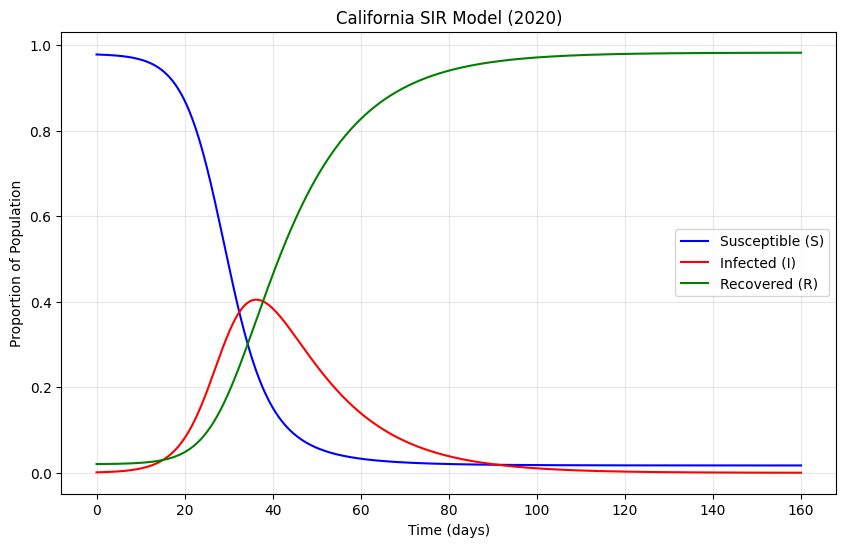

<Axes: title={'center': 'California SIR Model (2020)'}, xlabel='Time (days)', ylabel='Proportion of Population'>

In [47]:
t_2020, results_2020 = sir.run_sir_model(
    scaled_conditions[2020],
    beta=beta,
    gamma=gamma,
    days=160
)

sir.plot_sir_model(
    t_2020,
    results_2020,
    title="California SIR Model (2020)"
)

The 2020 simulation begins with a population that is overwhelmingly susceptible, with relatively few individuals estimated to have previously experienced infection. As a result, the model predicts substantial epidemic growth because a large proportion of the population remains available for transmission.

The infected compartment rises rapidly during the early stages of the simulation and reaches the highest peak among the three years considered in this analysis. As infections increase, the susceptible population declines and the recovered population grows steadily.

Once a sufficient portion of the population has transitioned out of the susceptible compartment, recoveries begin to outpace new infections and the infected population declines. This behavior reflects the classic epidemic curve predicted by the SIR model.

## 7.2 California: October 18, 2021

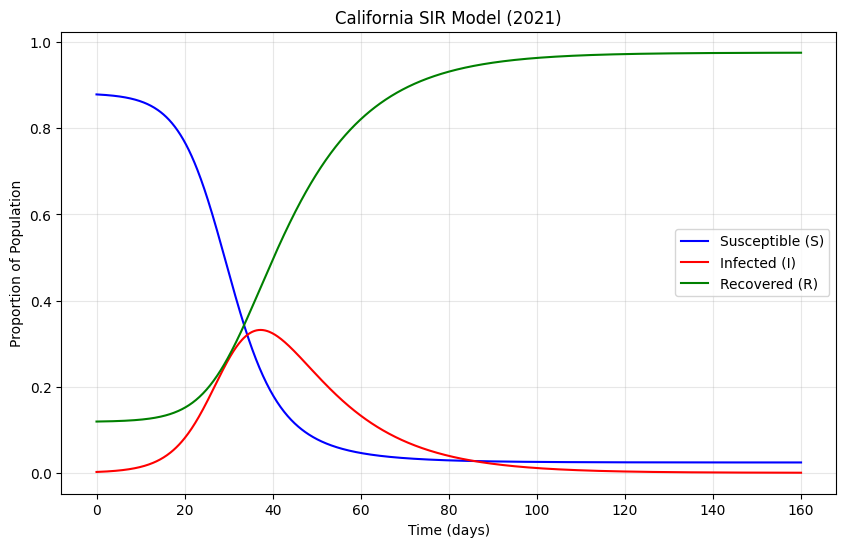

<Axes: title={'center': 'California SIR Model (2021)'}, xlabel='Time (days)', ylabel='Proportion of Population'>

In [48]:
t_2021, results_2021 = sir.run_sir_model(
    scaled_conditions[2021],
    beta=beta,
    gamma=gamma,
    days=160
)

sir.plot_sir_model(
    t_2021,
    results_2021,
    title="California SIR Model (2021)"
)

By October 2021, the estimated population composition differs substantially from the previous year. A larger proportion of the population is classified as recovered, while the susceptible population is correspondingly smaller.

Although the overall shape of the simulation remains similar to the 2020 scenario, epidemic growth occurs slightly more slowly and the infection peak is delayed. Because fewer individuals remain susceptible at the start of the simulation, disease transmission is somewhat constrained relative to the 2020 case.

The recovered compartment begins at a higher level and continues to increase throughout the simulation, reflecting the cumulative impact of infections that occurred during the first years of the pandemic.

## 7.3 California: October 18, 2022

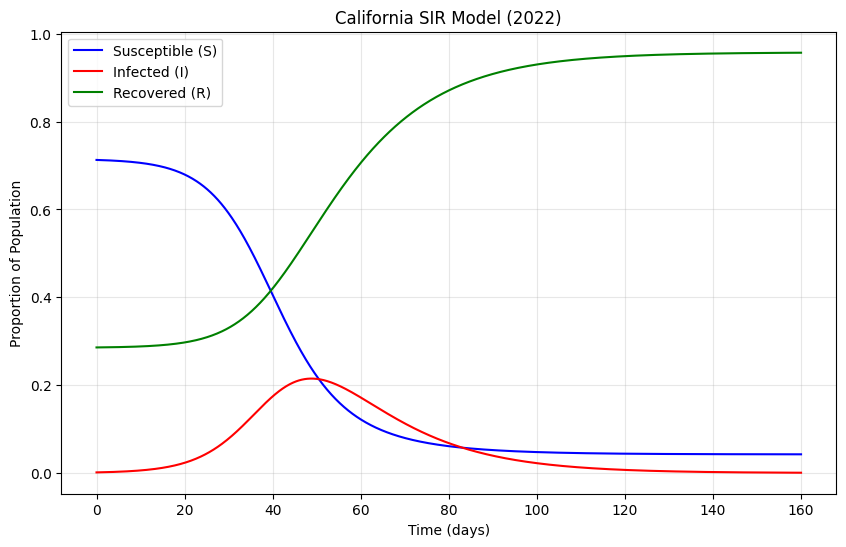

<Axes: title={'center': 'California SIR Model (2022)'}, xlabel='Time (days)', ylabel='Proportion of Population'>

In [49]:
t_2022, results_2022 = sir.run_sir_model(
    scaled_conditions[2022],
    beta=beta,
    gamma=gamma,
    days=160
)

sir.plot_sir_model(
    t_2022,
    results_2022,
    title="California SIR Model (2022)"
)

The 2022 simulation begins with the smallest susceptible population and the largest recovered population of the three scenarios. Nearly one-third of the population is estimated to have previously experienced infection, resulting in substantially different initial conditions.

Consequently, the model predicts a smaller infection peak than either the 2020 or 2021 simulations. With fewer susceptible individuals available for transmission, epidemic growth is more limited and the infected compartment never reaches the same magnitude observed in earlier years.

The recovered compartment begins at a much higher level and continues to grow throughout the simulation. This illustrates how changes in population composition can alter epidemic dynamics even when the transmission and recovery parameters remain unchanged.

## 7.4 Comparing Simulations Across Years

The three simulations demonstrate how changes in initial conditions influence epidemic behavior.

Although the same transmission and recovery parameters were used in each simulation, the resulting trajectories differ because the underlying population composition changes between years. The proportion of susceptible individuals decreases steadily from 2020 to 2022, while the recovered compartment increases substantially.

As a result, the model predicts progressively smaller infection peaks in later years. The 2020 scenario exhibits the greatest epidemic growth because the population is overwhelmingly susceptible, whereas the 2022 scenario produces the smallest infection peak due to the much larger recovered population.

This comparison highlights one of the central insights of compartmental epidemic models: the future trajectory of an outbreak depends not only on disease characteristics, but also on the state of the population at the beginning of the simulation.

In [50]:
summary = []

for year, results in {
    2020: results_2020,
    2021: results_2021,
    2022: results_2022
}.items():

    infected = results[:,1]

    peak_day = t[np.argmax(infected)]
    peak_infected = infected.max()

    summary.append(
        {
            "Year": year,
            "Peak Day": round(float(peak_day), 1),
            "Peak Infected Proportion": round(float(peak_infected), 4)
        }
    )

pd.DataFrame(summary)

,Year,Peak Day,Peak Infected Proportion
0,2020,36.4,0.4050
1,2021,37.3,0.3319
2,2022,48.8,0.2150


The quantitative summary reinforces the patterns observed in the simulation plots.

The predicted peak infected proportion decreases from approximately 40.5% in 2020 to 21.5% in 2022. At the same time, the timing of the peak shifts later in the simulation period, occurring around Day 36 in 2020 and Day 49 in 2022.

These differences arise despite using identical transmission and recovery parameters in each simulation. The only change is the composition of the population at the start of the model. As the susceptible population decreases and the recovered population increases, epidemic growth becomes progressively more constrained.

Together, these results demonstrate the importance of initial conditions in determining epidemic dynamics and help explain why outbreaks can behave differently even when modeled using the same disease-specific parameters.

# 8. Sensitivity Analysis

The previous simulations held the transmission and recovery parameters constant across years. However, these parameters can substantially influence epidemic behavior.

To illustrate this effect, the transmission rate is varied while holding all other model inputs constant.

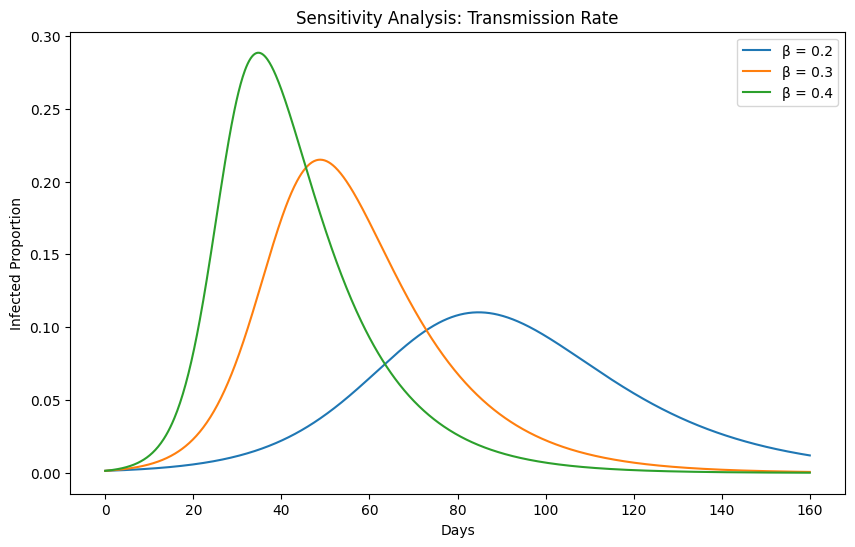

In [51]:
beta_values = [0.2, 0.3, 0.4]

plt.figure(figsize=(10,6))

for beta in beta_values:

    t, results = sir.run_sir_model(
        scaled_conditions[2022],
        beta=beta,
        gamma=1/14,
        days=160
    )

    plt.plot(
        t,
        results[:,1],
        label=f"β = {beta}"
    )

plt.title("Sensitivity Analysis: Transmission Rate")
plt.xlabel("Days")
plt.ylabel("Infected Proportion")
plt.legend()
plt.show()

The differences between the curves illustrate the nonlinear nature of epidemic growth.

When the transmission rate is increased, infections spread more rapidly through the susceptible population, producing earlier and larger peaks. Conversely, reducing the transmission rate slows epidemic growth and lowers the maximum infected proportion.

These results demonstrate why accurate estimation of transmission parameters is important in epidemiological modeling and why small changes in disease transmission can lead to substantially different outcomes.

# 9. Discussion and Limitations

This notebook demonstrates how publicly available surveillance data can be combined with a simple SIR framework to explore epidemic dynamics.

Several simplifying assumptions were required. First, active infections were estimated using a 14-day rolling case window because active case counts were not directly available in the CDC dataset. Second, recovered individuals were estimated indirectly from cumulative cases and deaths. Third, constant transmission and recovery rates were assumed throughout each simulation. In reality, these values vary over time due to behavioral changes, public health interventions, viral evolution, vaccination, and other factors. Finally, the model does not account for reinfections, vaccination, demographic heterogeneity, geographic variation, or population movement.

Additionally, the recovered compartment was estimated using cumulative reported cases and therefore does not account for underreporting, asymptomatic infections, or differences in testing availability throughout the pandemic.

Consequently, the simulations should be interpreted as educational demonstrations rather than epidemiological forecasts.

# 10. Conclusions

This notebook demonstrated how the `sir_modeling.py` module can be used to construct, simulate, and visualize SIR models using real-world COVID-19 surveillance data.

Beginning with the mathematical foundations of the SIR framework, the analysis showed how public health data can be transformed into model inputs and used to initialize epidemic simulations.

Comparisons across 2020, 2021, and 2022 highlighted how changes in population composition influence epidemic behavior. Sensitivity analysis further demonstrated the impact of transmission dynamics on model outcomes.

Although simplified, the workflow provides an accessible introduction to compartmental epidemic modeling and illustrates how mathematical models can be implemented and explored using Python.

# 11. References

## Data Sources

Centers for Disease Control and Prevention (CDC). *United States COVID-19 Cases and Deaths by State Over Time.*

United States Census Bureau. *Population Estimates Program.*

## Educational and Technical References

Mathematical Association of America. *The SIR Model for Spread of Disease.*

SciPy Documentation. *scipy.integrate.odeint.*

Pandas Documentation.

Matplotlib Documentation.